# Posture Detection V2 — 13 Final Real-Time Hybrid Application

This is the final V2 implementation notebook. It combines:

- asynchronous MotionBERT 3D lifting and personal upright calibration;
- a torso-normalized, mirror-corrected 57-feature Random Forest;
- green pose visualization and orange low-visibility feedback;
- confidence/OOD filtering and prediction smoothing;
- continuous 0–100 posture scoring;
- sustained-bad-posture duration tracking and smart alerts;
- session CSV, summary analytics, FPS, and inference latency.

**Safety rule:** MotionBERT alone determines `GOOD` versus `BAD`. The learned classifier only explains the direction of an already-bad posture, preventing its remaining upright/backward confusion from creating false bad-posture alerts.


## 1. Load the tested MotionBERT pipeline

Notebook 06 supplies the MotionBERT model and the previously tested 2D-to-3D, feature, and score functions. Its webcam loop is not executed.


In [1]:
import json
from pathlib import Path

wd=Path.cwd(); PROJECT_ROOT=wd.parent if wd.name=='notebooks' else wd if wd.name=='project_v2' else wd/'project_v2'
candidates=[PROJECT_ROOT/'posture_v2_06_realtime_webcam.ipynb',PROJECT_ROOT/'notebooks'/'posture_v2_06_realtime_webcam.ipynb']
NB6=next((p for p in candidates if p.exists()),None)
if NB6 is None: raise FileNotFoundError('Place posture_v2_06_realtime_webcam.ipynb in project_v2 or project_v2/notebooks.')
nb6=json.loads(NB6.read_text(encoding='utf-8'))
for index in (2,4): exec(''.join(nb6['cells'][index]['source']),globals())
print('MotionBERT device:',device)
print('Reused tested pipeline from:',NB6.resolve())


Device: cpu
MotionBERT device: cpu
Reused tested pipeline from: C:\Users\manth\Desktop\project_v2\posture_v2_06_realtime_webcam.ipynb


## 2. Load the final torso-normalized classifier contract

Notebook 12 must already have saved `multiposture_torso57_rf.joblib` and `multiposture_torso57_contract.json`.


In [2]:
import joblib, matplotlib.pyplot as plt, pandas as pd, numpy as np

RF_FILE=PROJECT_ROOT/'models'/'multiposture_torso57_rf.joblib'
CONTRACT_FILE=PROJECT_ROOT/'models'/'multiposture_torso57_contract.json'
for p in (RF_FILE,CONTRACT_FILE):
    if not p.exists(): raise FileNotFoundError(f'Run Notebook 12 first: {p}')

rf=joblib.load(RF_FILE)
if hasattr(rf,'n_jobs'): rf.n_jobs=1
contract=json.loads(CONTRACT_FILE.read_text(encoding='utf-8'))
FEATURE_COLUMNS=list(contract['feature_columns']); KEEP_INDICES=[int(i) for i in contract['landmark_indices']]; KEEP_NAMES=list(contract['landmark_names'])
MIN_PROB=float(contract['minimum_probability']); MAX_OOD=float(contract['maximum_ood_fraction'])
CORE_INDICES=[int(i) for i in contract['core_visibility_indices']]; CORE_MIN=float(contract['minimum_core_visibility'])
lower=pd.Series(contract['ood_lower'],dtype=float).reindex(FEATURE_COLUMNS); upper=pd.Series(contract['ood_upper'],dtype=float).reindex(FEATURE_COLUMNS)
ALL_NAMES=['nose','left_eye_inner','left_eye','left_eye_outer','right_eye_inner','right_eye','right_eye_outer','left_ear','right_ear','mouth_left','mouth_right','left_shoulder','right_shoulder','left_elbow','right_elbow','left_wrist','right_wrist','left_pinky','right_pinky','left_index','right_index','left_thumb','right_thumb','left_hip','right_hip','left_knee','right_knee','left_ankle','right_ankle','left_heel','right_heel','left_foot_index','right_foot_index']
if len(FEATURE_COLUMNS)!=57 or int(getattr(rf,'n_features_in_',-1))!=57 or lower.isna().any() or upper.isna().any():
    raise ValueError('Invalid Notebook 12 model/contract.')

def classifier_features(landmarks):
    xyz=np.array([[p.x,p.y,p.z] for p in landmarks],np.float32); hip=(xyz[23]+xyz[24])/2; xyz-=hip
    shoulder=(xyz[11]+xyz[12])/2; scale=max(float(np.linalg.norm(shoulder)),1e-6); xyz/=scale
    xyz[:,0]*=-1
    for left in [n for n in KEEP_NAMES if n.startswith('left_')]:
        right='right_'+left[5:]
        if right in ALL_NAMES:
            li,ri=ALL_NAMES.index(left),ALL_NAMES.index(right); xyz[[li,ri]]=xyz[[ri,li]]
    values={f'{name}_{axis}':float(xyz[i,j]) for i,name in zip(KEEP_INDICES,KEEP_NAMES) for j,axis in enumerate('xyz')}
    return pd.DataFrame([[values[c] for c in FEATURE_COLUMNS]],columns=FEATURE_COLUMNS)

def classify_direction(landmarks):
    x=classifier_features(landmarks); ood=float(((x.iloc[0]<lower)|(x.iloc[0]>upper)).mean())
    probabilities=rf.predict_proba(x)[0]; k=int(np.argmax(probabilities))
    return str(rf.classes_[k]),float(probabilities[k]),ood,ood<=MAX_OOD

print('Classes:',list(rf.classes_)); print('Features:',len(FEATURE_COLUMNS))
print(f'Gates: probability >= {MIN_PROB:.0%}, OOD <= {MAX_OOD:.0%}, core visibility >= {CORE_MIN:.0%}')


Classes: ['lean_backward', 'lean_forward', 'lean_left', 'lean_right', 'upright']
Features: 57
Gates: probability >= 55%, OOD <= 20%, core visibility >= 35%


## 3. Run the final application

Instructions:

1. Sit upright and keep shoulders and hips visible during the eight calibration updates.
2. A **green skeleton** means visibility is sufficient; **orange** means move back or reveal your hips.
3. A bad posture must persist for 10 seconds before the alert activates.
4. Press **C** to recalibrate, **Q** to save and quit.


In [3]:
from collections import Counter,deque
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
import time

CAMERA_INDEX=0; WINDOW=81; STRIDE=27; CALIBRATION_UPDATES=8; CLASS_SMOOTH=15
BAD_SCORE_THRESHOLD=70.; ALERT_AFTER_SECONDS=10.
POSE_CONNECTIONS=[(0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),(11,12),(11,13),(13,15),(15,17),(17,19),(19,15),(15,21),(12,14),(14,16),(16,18),(18,20),(20,16),(16,22),(11,23),(12,24),(23,24),(23,25),(25,27),(27,29),(29,31),(31,27),(24,26),(26,28),(28,30),(30,32),(32,28)]

def draw_skeleton(frame,landmarks,core_ok):
    h,w=frame.shape[:2]; color=(0,255,0) if core_ok else (0,165,255); points=[]
    for p in landmarks:
        visible=min(p.visibility,getattr(p,'presence',p.visibility))>=.35; inside=0<=p.x<=1 and 0<=p.y<=1
        points.append((int(p.x*w),int(p.y*h)) if visible and inside else None)
    for a,b in POSE_CONNECTIONS:
        if points[a] is not None and points[b] is not None: cv2.line(frame,points[a],points[b],color,3,cv2.LINE_AA)
    for point in points:
        if point is not None: cv2.circle(frame,point,4,color,-1,cv2.LINE_AA)

def sound_alert():
    try:
        import winsound; winsound.Beep(950,250)
    except Exception:
        print('\a',end='',flush=True)

Base=mp.tasks.BaseOptions; Landmarker=mp.tasks.vision.PoseLandmarker; Options=mp.tasks.vision.PoseLandmarkerOptions; Mode=mp.tasks.vision.RunningMode
opts=Options(base_options=Base(model_asset_path=str(MODEL_TASK)),running_mode=Mode.VIDEO,num_poses=1,min_pose_detection_confidence=.5,min_pose_presence_confidence=.5,min_tracking_confidence=.5)
cap=cv2.VideoCapture(CAMERA_INDEX); cap.set(cv2.CAP_PROP_FRAME_WIDTH,1280); cap.set(cv2.CAP_PROP_FRAME_HEIGHT,720)
if not cap.isOpened(): raise RuntimeError('Could not open webcam.')

buffer=deque(maxlen=WINDOW); votes=deque(maxlen=CLASS_SMOOTH); executor=ThreadPoolExecutor(max_workers=1); future=None
calibration=[]; baseline=scale=None; score=None; rule_issue='none'; final_issue='none'; latency=np.nan
history=[]; frame_id=0; started=time.perf_counter(); previous_frame=started; fps_ema=np.nan
status='BUFFERING'; learned='uncertain'; raw_label='unknown'; prob=np.nan; ood=np.nan; trusted=False
bad_since=None; bad_duration=0.; alerted=False; alert_count=0

with Landmarker.create_from_options(opts) as detector:
  try:
    while True:
      ok,frame=cap.read()
      if not ok: break
      frame=cv2.flip(frame,1); now=time.perf_counter(); dt=max(now-previous_frame,1e-6); previous_frame=now
      instant_fps=1/dt; fps_ema=instant_fps if np.isnan(fps_ema) else .9*fps_ema+.1*instant_fps
      h,w=frame.shape[:2]; ts=int((now-started)*1000)
      result=detector.detect_for_video(mp.Image(image_format=mp.ImageFormat.SRGB,data=cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)),ts)
      detected=bool(result.pose_landmarks); core_visibility=0.; core_ok=False
      if detected:
        landmarks=result.pose_landmarks[0]; core_visibility=float(min(min(landmarks[i].visibility,getattr(landmarks[i],'presence',landmarks[i].visibility)) for i in CORE_INDICES)); core_ok=core_visibility>=CORE_MIN; draw_skeleton(frame,landmarks,core_ok)
      if detected and core_ok:
        buffer.append(to_h36m(landmarks)); raw_label,prob,ood,trusted=classify_direction(landmarks)
        if trusted and prob>=MIN_PROB: votes.append(raw_label)
        else: votes.clear()
        learned=Counter(votes).most_common(1)[0][0] if votes else 'uncertain'
      else:
        buffer.clear(); votes.clear(); learned='low confidence'; raw_label='unknown'; prob=np.nan; ood=np.nan; trusted=False

      if future is not None and future.done():
        pose3d,latency=future.result(); value=features(pose3d)
        if baseline is None:
          calibration.append(value); status=f'CALIBRATING {len(calibration)}/{CALIBRATION_UPDATES}'
          if len(calibration)>=CALIBRATION_UPDATES:
            a=np.stack(calibration); baseline=np.median(a,axis=0); scale=np.maximum(1.4826*np.median(np.abs(a-baseline),axis=0),FLOOR); status='CALIBRATED'
        else:
          score,rule_issue,severity=score_pose(value,baseline,scale)
          state='BAD' if score<BAD_SCORE_THRESHOLD else 'GOOD'
          if state=='BAD':
            if bad_since is None: bad_since=now; alerted=False
            bad_duration=now-bad_since
            if bad_duration>=ALERT_AFTER_SECONDS and not alerted: sound_alert(); alerted=True; alert_count+=1
          else:
            bad_since=None; bad_duration=0.; alerted=False
          classifier_issue=learned if learned not in ('upright','uncertain','low confidence') else None
          final_issue=(classifier_issue or rule_issue) if state=='BAD' else 'none'
          status='BAD - ALERT' if state=='BAD' and alerted else state
          history.append({'utc':datetime.now(timezone.utc).isoformat(),'seconds':now-started,'score':score,'state':state,'final_issue':final_issue,'rule_issue':rule_issue,'raw_classifier_label':raw_label,'smoothed_classifier_label':learned,'classifier_probability':prob,'ood_fraction':ood,'classifier_trusted':trusted,'core_visibility':core_visibility,'bad_duration_seconds':bad_duration,'alert_active':alerted,'motionbert_latency_ms':latency,'display_fps':fps_ema})
        future=None

      if len(buffer)==WINDOW and frame_id%STRIDE==0 and future is None: future=executor.submit(lift,prepare(np.stack(buffer),w,h))
      if not detected: status_line='NO POSE'
      elif not core_ok: status_line=f'MOVE BACK / SHOW HIPS  core:{core_visibility:.0%}'
      else: status_line=status
      color=(0,220,0) if status in ('GOOD','CALIBRATED') else (0,165,255) if 'CALIB' in status or status in ('BUFFERING','NO POSE') or not core_ok else (0,0,255)
      cv2.putText(frame,status_line,(25,40),cv2.FONT_HERSHEY_SIMPLEX,.85,color,2)
      learned_text=f'{learned}  p:{prob:.0%}  OOD:{ood:.0%}' if np.isfinite(prob) else learned
      cv2.putText(frame,f'Direction: {learned_text}',(25,78),cv2.FONT_HERSHEY_SIMPLEX,.62,(255,255,255),2)
      if score is not None:
        cv2.putText(frame,f'Score: {score:.1f}  Issue: {final_issue}  Bad: {bad_duration:.1f}s',(25,114),cv2.FONT_HERSHEY_SIMPLEX,.62,color,2)
      cv2.putText(frame,f'FPS: {fps_ema:.1f}  MotionBERT: {latency:.0f}ms  Alerts: {alert_count}',(25,150),cv2.FONT_HERSHEY_SIMPLEX,.58,(255,255,255),2)
      cv2.putText(frame,'Q quit/save | C recalibrate',(25,h-25),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,255,255),1)
      cv2.imshow('Posture Detection V2 - Final',frame)
      key=cv2.waitKey(1)&0xFF
      if key==ord('q'): break
      if key==ord('c'):
        calibration=[]; baseline=scale=None; score=None; votes.clear(); buffer.clear(); bad_since=None; bad_duration=0.; alerted=False; status='RECALIBRATING'
      frame_id+=1
  finally:
    cap.release(); cv2.destroyAllWindows(); executor.shutdown(wait=True)

session=pd.DataFrame(history); stamp=datetime.now().strftime('%Y%m%d_%H%M%S'); csv_file=OUTPUT_DIR/f'final_v2_session_{stamp}.csv'; session.to_csv(csv_file,index=False)
print('Saved session:',csv_file.resolve())
if session.empty: print('No scored updates were recorded. Complete calibration and continue briefly before quitting.')
else: display(session.tail())


Saved session: C:\Users\manth\Desktop\project_v2\results\webcam_sessions\final_v2_session_20260925_005116.csv


,utc,seconds,score,state,final_issue,rule_issue,raw_classifier_label,smoothed_classifier_label,classifier_probability,ood_fraction,classifier_trusted,core_visibility,bad_duration_seconds,alert_active,motionbert_latency_ms,display_fps
2,2026-09-24T19:18:56.347081+00:00,76.708432,100.000000,GOOD,none,none,lean_forward,lean_forward,0.739373,0.035088,True,0.864063,0.000000,False,1720.6183,7.460797
3,2026-09-24T19:19:00.277788+00:00,80.641500,100.000000,GOOD,none,none,lean_forward,lean_forward,0.721399,0.035088,True,0.902778,0.000000,False,2137.0422,6.961083
4,2026-09-24T19:19:54.750831+00:00,135.064737,46.978545,BAD,lean_right,leaning,lean_right,lean_right,0.678762,0.087719,True,0.762468,0.000000,False,2060.9666,7.243411
5,2026-09-24T19:20:57.451106+00:00,197.501429,65.232600,BAD,lean_forward,slouching,lean_forward,lean_forward,0.781319,0.035088,True,0.611329,62.436693,True,2110.7325,7.116134
6,2026-09-24T19:21:00.961798+00:00,201.382281,86.839387,GOOD,none,shoulder imbalance,unknown,low confidence,NaN,NaN,False,0.124145,0.000000,False,1641.1487,10.280226


## 4. Session summary and timeline

Run automatically after the webcam closes. Percentages are time-weighted between MotionBERT updates.


,value
scored_updates,7
tracked_seconds,131.470633
good_percent,11.113284
bad_percent,88.886716
bad_duration_seconds,116.859929
common_issue,lean_forward
alerts,1
median_score,86.839387
median_motionbert_latency_ms,2060.9666
median_display_fps,7.243411


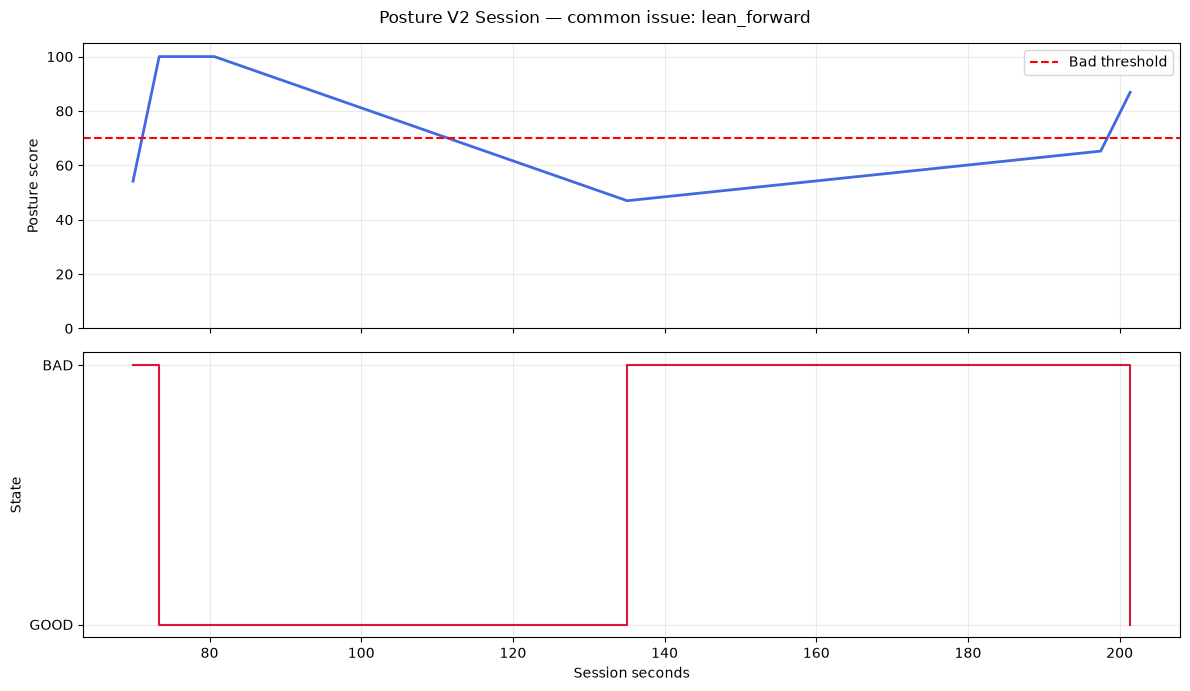

Saved summary: C:\Users\manth\Desktop\project_v2\results\webcam_sessions\final_v2_summary_20260925_005116.json
Saved timeline: C:\Users\manth\Desktop\project_v2\results\webcam_sessions\final_v2_timeline_20260925_005116.png


In [4]:
if len(session):
    intervals=session['seconds'].diff().fillna(0).clip(lower=0)
    total_seconds=float(intervals.sum()); good_seconds=float(intervals.where(session['state'].eq('GOOD'),0).sum()); bad_seconds=float(intervals.where(session['state'].eq('BAD'),0).sum())
    issues=session.loc[session['final_issue'].ne('none'),'final_issue']; common_issue=issues.mode().iat[0] if len(issues) else 'none'
    summary=pd.Series({'scored_updates':len(session),'tracked_seconds':total_seconds,'good_percent':100*good_seconds/max(total_seconds,1e-6),'bad_percent':100*bad_seconds/max(total_seconds,1e-6),'bad_duration_seconds':bad_seconds,'common_issue':common_issue,'alerts':int(session['alert_active'].astype(int).diff().fillna(session['alert_active'].astype(int)).gt(0).sum()),'median_score':session['score'].median(),'median_motionbert_latency_ms':session['motionbert_latency_ms'].median(),'median_display_fps':session['display_fps'].median(),'classifier_trusted_percent':session['classifier_trusted'].mean()*100})
    display(summary.to_frame('value'))
    summary_file=OUTPUT_DIR/f'final_v2_summary_{stamp}.json'; summary_file.write_text(json.dumps({k:(v.item() if hasattr(v,'item') else v) for k,v in summary.items()},indent=2),encoding='utf-8')

    fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
    axes[0].plot(session['seconds'],session['score'],color='royalblue',linewidth=2); axes[0].axhline(BAD_SCORE_THRESHOLD,color='red',linestyle='--',label='Bad threshold'); axes[0].set_ylabel('Posture score'); axes[0].set_ylim(0,105); axes[0].legend(); axes[0].grid(alpha=.25)
    bad=session['state'].eq('BAD').astype(int); axes[1].step(session['seconds'],bad,where='post',color='crimson'); axes[1].set_yticks([0,1],['GOOD','BAD']); axes[1].set_xlabel('Session seconds'); axes[1].set_ylabel('State'); axes[1].grid(alpha=.25)
    fig.suptitle(f'Posture V2 Session — common issue: {common_issue}'); fig.tight_layout()
    chart_file=OUTPUT_DIR/f'final_v2_timeline_{stamp}.png'; fig.savefig(chart_file,dpi=150,bbox_inches='tight'); plt.show()
    print('Saved summary:',summary_file.resolve()); print('Saved timeline:',chart_file.resolve())


## Project complete

Notebook 13 is the final V2 application. Its saved session CSV, JSON summary, and timeline image provide the final runtime evidence. Earlier notebooks remain the reproducible development and validation trail; no Notebook 14 is required.
